# Phase 2 — Data Exploration
**Goal:** Verify the dataset loaded correctly, check class balance, and visually confirm that augmentation is working as expected before we start training.

In [2]:
import sys, os

# Add the project root to Python's module search path.
# The notebook lives in /notebooks, so we go up one level (..) to reach the root,
# which lets us do 'from src.preprocess import ...' in the next cell.
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from src.preprocess import get_generators, TRAIN_DIR, IMG_SIZE

## 1. Load the generators and check what Keras found

In [3]:
# Build the three generators defined in src/preprocess.py.
# Keras will print how many images it found per split — check that these look right.
train_gen, val_gen, test_gen = get_generators()

# class_indices maps each folder name to an integer index.
# e.g. {'asian': 0, 'coastal': 1, ...}
# This is how the model knows which number corresponds to which style.
print("Class → index mapping:")
for name, idx in train_gen.class_indices.items():
    print(f"  {idx:>2}  {name}")

print(f"\nTraining images:   {train_gen.samples}")
print(f"Validation images: {val_gen.samples}")
print(f"Test images:       {test_gen.samples}")

Found 12654 images belonging to 19 classes.
Found 2222 images belonging to 19 classes.
Found 3729 images belonging to 19 classes.
Class → index mapping:
   0  asian
   1  coastal
   2  contemporary
   3  craftsman
   4  eclectic
   5  farmhouse
   6  french-country
   7  industrial
   8  mediterranean
   9  mid-century-modern
  10  modern
  11  rustic
  12  scandinavian
  13  shabby-chic-style
  14  southwestern
  15  traditional
  16  transitional
  17  tropical
  18  victorian

Training images:   12654
Validation images: 2222
Test images:       3729


## 2. Class balance check
We need roughly equal images per class. If one class has far more images than others, the model will be biased toward predicting it more often.

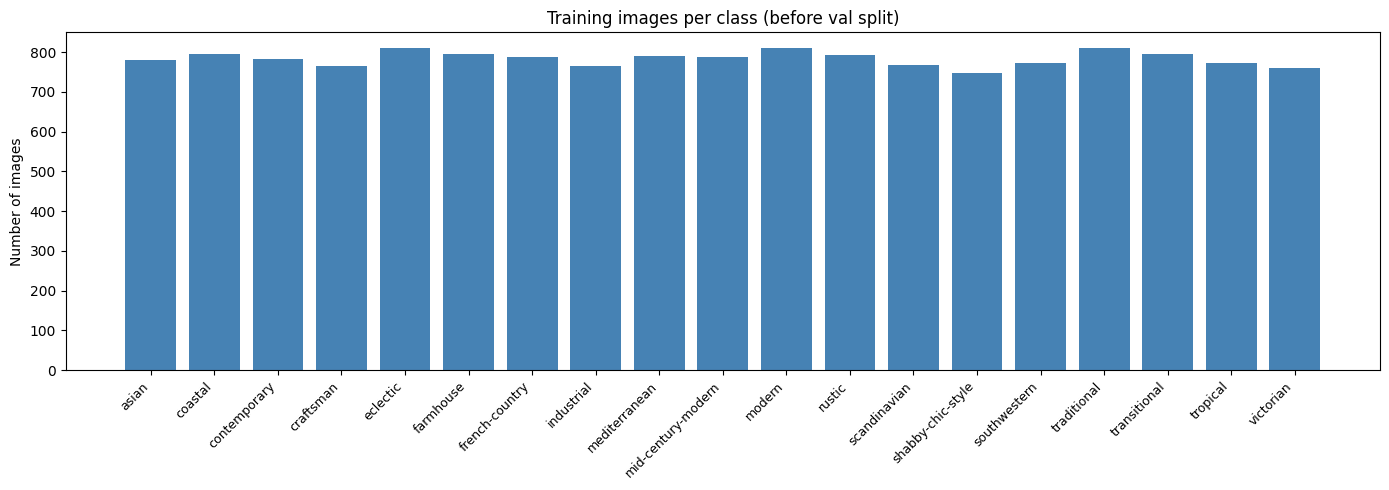

Min: 746 images  |  Max: 809 images  |  Difference: 63
→ A small difference here is fine. A large difference (>2×) would require class weighting.


In [4]:
# Count images in each class folder directly from disk.
class_names = list(train_gen.class_indices.keys())
counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in class_names]

plt.figure(figsize=(14, 5))
bars = plt.bar(class_names, counts, color='steelblue')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Number of images')
plt.title('Training images per class (before val split)')
plt.tight_layout()
plt.show()

print(f"Min: {min(counts)} images  |  Max: {max(counts)} images  |  Difference: {max(counts)-min(counts)}")
print("→ A small difference here is fine. A large difference (>2×) would require class weighting.")

## 3. Sample images from the training generator
Grab one batch and display it. This confirms the images loaded, resized correctly to 224×224, and labels match the right classes.

In [ ]:
import numpy as np

# preprocess_input subtracts ImageNet channel means so values land in ~[-128, 151].
# imshow expects [0, 1] floats or [0, 255] uint8, so we reverse the shift for display only.
# This does NOT affect training — it's purely for visualisation here.
_IMAGENET_MEAN = np.array([103.939, 116.779, 123.68])   # BGR means used by preprocess_input

def deprocess(img):
    """Reverse preprocess_input so imshow displays natural colours."""
    img = img.copy()
    img += _IMAGENET_MEAN          # add back the channel means
    img = img[..., ::-1]           # BGR → RGB
    img = np.clip(img, 0, 255).astype('uint8')
    return img

# next() pulls one batch from the generator.
# images shape: (32, 224, 224, 3) — 32 preprocessed images (values ~[-128, +151])
# labels shape: (32, 19)          — one-hot encoded, 19 classes
images, labels = next(train_gen)

label_indices = np.argmax(labels, axis=1)

fig, axes = plt.subplots(4, 8, figsize=(18, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(deprocess(images[i]))
    ax.set_title(class_names[label_indices[i]], fontsize=7)
    ax.axis('off')
plt.suptitle('One training batch — 32 images (augmentation may be applied)', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Image array shape:        {images.shape}")
print(f"Preprocessed value range: [{images.min():.1f}, {images.max():.1f}]  ← ~[-128, +151] after ResNet50 preprocess_input")

## 4. Augmentation preview
Take one image and generate 10 augmented versions of it. This lets us visually confirm the augmentation parameters look natural and not too aggressive.

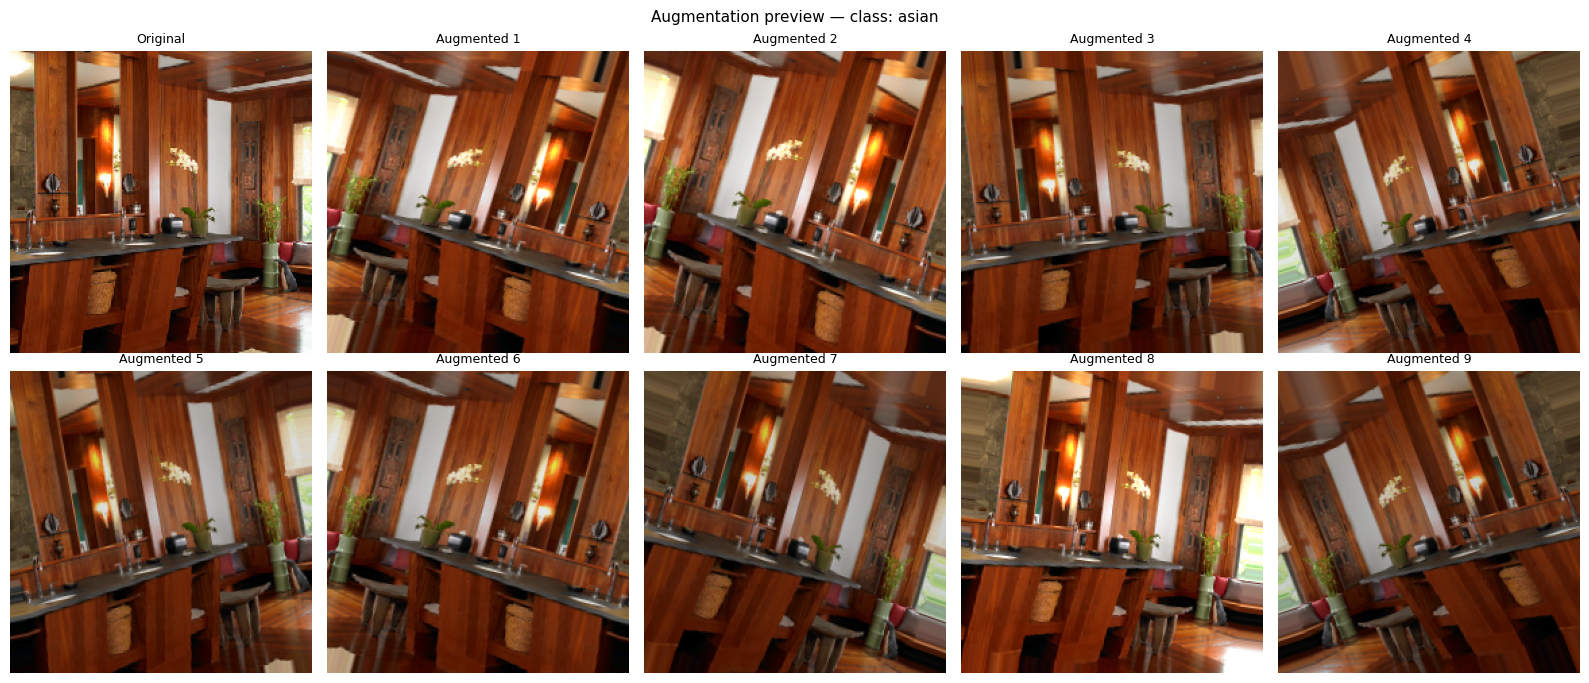

In [6]:
# Pick the first image from the first class folder as our sample.
sample_class = class_names[0]
sample_folder = os.path.join(TRAIN_DIR, sample_class)
sample_file = os.path.join(sample_folder, os.listdir(sample_folder)[0])

# Load the image and reshape to (1, 224, 224, 3) — the generator expects a batch dimension.
img = load_img(sample_file, target_size=IMG_SIZE)
img_array = img_to_array(img).reshape((1, 224, 224, 3))

# Recreate the augmentation generator (without rescaling so colours display naturally).
aug_preview = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1
)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes.flat[0].imshow(img)                        # First tile = original image
axes.flat[0].set_title('Original', fontsize=9)
axes.flat[0].axis('off')

for i, ax in enumerate(axes.flat[1:], start=1):
    augmented = next(aug_preview.flow(img_array))[0].astype('uint8')
    ax.imshow(augmented)
    ax.set_title(f'Augmented {i}', fontsize=9)
    ax.axis('off')

plt.suptitle(f'Augmentation preview — class: {sample_class}', fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
import sys
print(sys.version)

3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]


In [8]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.21.0
[]
